# MES KAMA/SMA crossover on 1-minute candles -- selection on 30%, validation on 70%

**Revision note**: the first version of this notebook searched lengths and the
SL bracket on the *full* sample (winner: KAMA(30)/SMA(7680) + sl 2% / tp 3%,
Sharpe 0.916) -- decent-looking numbers with no out-of-sample discipline behind
them. This revision redoes the whole exercise honestly:

**Protocol** (chronological, no shuffling -- market data is a time series):
- **Selection set ("test"): the first 30%** of the 1-minute history
  (2019-05 -> ~2021-07). *Everything* tunable -- KAMA length, SMA length,
  stop-loss, take-profit ratio -- is chosen here and only here.
- **Validation set: the remaining 70%** (~2021-07 -> 2026-07). The single
  frozen configuration is run here once, against a no-bracket reference. No
  peeking, no re-picking: whatever it shows is the result.

A 30/70 split is deliberately conservative -- the selection window is small and
the verdict window is ~5 years spanning multiple regimes (2022 hikes, 2023-24
mega-cap rally, 2025-26). A configuration that only worked because it was
tuned on 2019-2021 has nowhere to hide.

**Wider search ranges than v1** (per the brief): KAMA fast lengths 10 minutes
-> 64 hours; SMA slow lengths 30 minutes -> ~10.7 trading days (v1's winner sat
exactly on its SMA grid boundary of 7680, so the range now extends well past
it); SL 0.5% -> 8% of entry price; TP searched as a ratio of SL in
{1.5x, 2x, 3x} instead of pinned at 1.5x.

Costs, ranking metric (`trade_sharpe_lb`), long-only side, and the real
event-driven engine for anything bracket-related are all unchanged from v1 and
from `step_1_find_best_indicators_and_parameters.ipynb`.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import multiprocess as mp
import numpy as np
import pandas as pd
import pandas_ta as ta
from IPython.display import HTML, display
from tqdm import tqdm

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.performance import metrics as perf_metrics
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MaCrossoverStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/tradovate_ma_crossover/MES


In [2]:
DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 1
UNIT_OF_TIME = "minute"
SIDE = "long"

mes_config = TRADOVATE_FUTURES[DISPLAY_SYMBOL]
POINT_VALUE = mes_config.point_value
TICK_SIZE = mes_config.tick_size
SLIPPAGE_TICKS = mes_config.slippage_ticks
FEE_PER_CONTRACT = mes_config.fee_per_contract_override

print(f"MES cost model: tick_size={TICK_SIZE}pt (${TICK_SIZE*POINT_VALUE}/tick), "
      f"slippage={SLIPPAGE_TICKS} tick/side, commission=${FEE_PER_CONTRACT}/side")


def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


PARQUET_PATH = _find_upwards(
    "apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd)
)
df = load_1m_parquet_resampled(PARQUET_PATH, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
prices = df["close"]
rs = prices.apply(np.log).diff(1)

SELECTION_FRACTION = 0.30
split_idx = int(len(prices) * SELECTION_FRACTION)
SPLIT_TS = prices.index[split_idx]
df_sel = df.iloc[:split_idx]
sel_prices = prices.iloc[:split_idx]
sel_rs = rs.iloc[:split_idx]

print(f"Full span:       {prices.index[0]} -> {prices.index[-1]} ({len(prices)} bars)")
print(f"SELECTION (30%): {sel_prices.index[0]} -> {sel_prices.index[-1]} ({len(sel_prices)} bars)")
print(f"VALIDATION (70%): {SPLIT_TS} -> {prices.index[-1]} ({len(prices) - split_idx} bars)")


def backtest_side(val, side=SIDE):
    if side == "both":
        return np.sign(val)
    if side == "long":
        return 1 if val > 0 else 0
    if side == "short":
        return -1 if val < 0 else 0
    raise ValueError(side)


def evaluate_signal(ma_x: pd.Series, eval_prices: pd.Series, eval_rs: pd.Series) -> dict:
    """Same cost-aware scorecard as step_1/v1: real Tradovate slippage+commission on
    every position change, daily-resampled risk metrics, trade-level Sharpe lower
    bound (Lo 2002) as the trust-weighted ranking metric."""
    pos = ma_x.apply(backtest_side)
    pos_exec = pos.shift(1).fillna(0)

    dpos = pos_exec.diff().fillna(pos_exec)
    units_traded = dpos.abs()

    slippage_price_equivalent = SLIPPAGE_TICKS * TICK_SIZE
    fee_price_equivalent = FEE_PER_CONTRACT / POINT_VALUE
    cost_percent = (slippage_price_equivalent + fee_price_equivalent) / eval_prices
    cost_rs = units_traded * np.log1p(-cost_percent)

    net_rs = pos_exec * eval_rs + cost_rs
    total_return = float(np.exp(net_rs.sum()) - 1)

    daily_log_returns = net_rs.resample("D").sum()
    daily_simple_returns = np.expm1(daily_log_returns)
    daily_cum = np.exp(daily_log_returns.cumsum())
    n_days = (daily_cum.index[-1] - daily_cum.index[0]).days or 1
    ann_return = perf_metrics.cagr(float(daily_cum.iloc[-1]), n_days)
    high_watermark = daily_cum.cummax()
    drawdown = (high_watermark - daily_cum) / high_watermark * -1
    max_dd = float(drawdown.min())

    sharpe = perf_metrics.sharpe_ratio(daily_simple_returns)
    calmar = perf_metrics.calmar_ratio(ann_return, max_dd)

    trade_id = (pos_exec != pos_exec.shift(1)).cumsum()
    in_trade = pos_exec != 0
    trade_log_returns = net_rs[in_trade].groupby(trade_id[in_trade]).sum()
    trade_returns = np.expm1(trade_log_returns)
    n_trades = len(trade_returns)
    trades_per_year = n_trades / (n_days / 365.25) if n_days else 0.0

    if n_trades >= 2:
        trade_sharpe = perf_metrics.sharpe_ratio(trade_returns, periods_per_year=trades_per_year)
        trade_sharpe_lb = perf_metrics.sharpe_lower_bound(trade_returns, periods_per_year=trades_per_year)
        win_rate = float((trade_returns > 0).mean())
    else:
        trade_sharpe = trade_sharpe_lb = win_rate = 0.0

    return {
        "total_return": total_return,
        "sharpe": sharpe,
        "calmar": calmar,
        "max_drawdown": max_dd,
        "trades": n_trades,
        "trades_per_year": trades_per_year,
        "win_rate": win_rate,
        "trade_sharpe": trade_sharpe,
        "trade_sharpe_lb": trade_sharpe_lb,
    }


MES cost model: tick_size=0.25pt ($1.25/tick), slippage=1.0 tick/side, commission=$0.91/side


Full span:       2019-05-05 22:00:59.999000 -> 2026-07-12 23:07:59.999000 (2508061 bars)
SELECTION (30%): 2019-05-05 22:00:59.999000 -> 2021-07-14 22:13:59.999000 (752418 bars)
VALIDATION (70%): 2021-07-14 22:14:59.999000 -> 2026-07-12 23:07:59.999000 (1755643 bars)


## Phase 1 (selection set only): KAMA/SMA length grid, widened

Indicators are computed **on the selection slice only** -- the grid never sees a
single validation bar. Kaufman-default smoothing (`fast=2, slow=30`) throughout.


In [3]:
KAMA_LENGTHS = [10, 20, 30, 45, 60, 90, 120, 240, 480, 960, 1920, 3840]        # 10min ... 64h
SMA_LENGTHS = [30, 60, 120, 240, 480, 960, 1920, 3840, 7680, 11520, 15360]     # 30min ... ~10.7 days
MIN_TRADES = 10


def _run_one_kama_length(kama_len):
    kama = ta.kama(sel_prices, length=kama_len, fast=2, slow=30)
    rows = []
    for sma_len in SMA_LENGTHS:
        if sma_len <= kama_len:
            continue
        ma_x = kama - sel_prices.rolling(sma_len).mean()
        result = evaluate_signal(ma_x, sel_prices, sel_rs)
        result["kama_len"] = kama_len
        result["sma_len"] = sma_len
        rows.append(result)
    return rows


pool = mp.Pool(5, maxtasksperchild=2)
sel_grid = pd.DataFrame(
    [row for rows in tqdm(pool.imap(_run_one_kama_length, KAMA_LENGTHS), total=len(KAMA_LENGTHS))
     for row in rows]
)
pool.close()

REPORT_COLUMNS = [
    "kama_len", "sma_len", "total_return", "trade_sharpe_lb", "trade_sharpe",
    "sharpe", "calmar", "max_drawdown", "trades", "trades_per_year", "win_rate",
]
sel_candidates = sel_grid[(sel_grid["total_return"] > 0) & (sel_grid["trades"] >= MIN_TRADES)]
sel_ranked = sel_candidates.sort_values("trade_sharpe_lb", ascending=False)
print(f"{len(sel_ranked)}/{len(sel_grid)} combos profitable with >= {MIN_TRADES} trades on the selection set")
print(sel_ranked[REPORT_COLUMNS].head(15).to_string())


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=96876) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=96876) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=96876) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=96876) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=96876) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


...

/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=96876) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/Users/nick/Documents/www/alphakit/.venv/lib/python3.13/site-packages/multiprocess/popen_fork.py:67: DeprecationWarning: This process (pid=96876) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


 92%|█████████▏| 11/12 [00:11<00:00,  1.21it/s]

100%|██████████| 12/12 [00:11<00:00,  1.08it/s]

50/93 combos profitable with >= 10 trades on the selection set
    kama_len  sma_len  total_return  trade_sharpe_lb  trade_sharpe    sharpe    calmar  max_drawdown  trades  trades_per_year  win_rate
19        20     7680      0.520340         0.557700      1.564811  1.415229  2.328298     -0.090340     258       117.646067  0.217054
57        90     7680      0.526374         0.552976      1.557500  1.428551  2.390651     -0.088898     163        74.326779  0.300613
92      3840    15360      0.452733         0.537274      1.533257  1.284855  1.771689     -0.104708      59        26.903558  0.355932
65       120     7680      0.498891         0.519692      1.506227  1.376714  2.134175     -0.094897     141        64.294944  0.333333
48        60     7680      0.512680         0.516777      1.501757  1.393624  2.167616     -0.095753     186        84.814607  0.268817
29        30     7680      0.495257         0.515411      1.499665  1.364106  2.199239     -0.091485     229       104.42

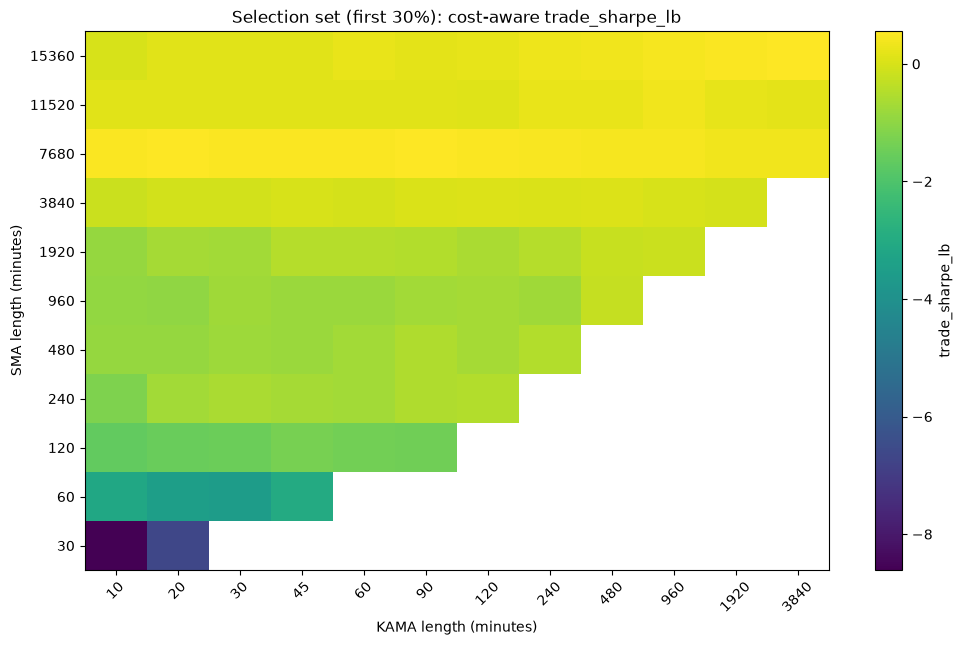

Frozen lengths: KAMA(20) / SMA(7680)  (selection trade_sharpe_lb=0.5577, net=+52.03%, trades=258)


In [4]:
pivot = sel_grid.pivot(index="sma_len", columns="kama_len", values="trade_sharpe_lb")
plt.figure(figsize=(12, 7))
plt.imshow(pivot.values, aspect="auto", cmap="viridis", origin="lower")
plt.colorbar(label="trade_sharpe_lb")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("KAMA length (minutes)")
plt.ylabel("SMA length (minutes)")
plt.title("Selection set (first 30%): cost-aware trade_sharpe_lb")
plt.show()

if not sel_candidates.empty:
    _best = sel_candidates.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
else:
    _best = sel_grid.sort_values("trade_sharpe_lb", ascending=False).iloc[0]
    print("WARNING: nothing profitable on the selection set -- falling back to the "
          "unfiltered argmax; the validation run below is then purely diagnostic.")

BEST_KAMA_LEN = int(_best["kama_len"])
BEST_SMA_LEN = int(_best["sma_len"])
print(f"Frozen lengths: KAMA({BEST_KAMA_LEN}) / SMA({BEST_SMA_LEN})  "
      f"(selection trade_sharpe_lb={_best['trade_sharpe_lb']:.4f}, "
      f"net={_best['total_return']:+.2%}, trades={int(_best['trades'])})")


## Phase 2 (selection set only): SL x TP-ratio grid through the real engine

Wider than v1 on both axes: SL in {0.5%, 0.75%, 1%, 1.5%, 2%, 3%, 5%, 8%} of
entry price, TP ratio in {1.5x, 2x, 3x} of SL -- 24 bracket combos plus a
no-bracket baseline, all on the selection slice only (indicators computed on
that slice, so nothing leaks). The selection-set market is compiled once and
shared across runs.


In [5]:
SL_CANDIDATES = [0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05, 0.08]
TP_RATIO_CANDIDATES = [1.5, 2.0, 3.0]
DEPOSIT_USD = 50_000

market_sel = Market()
market_sel.add_market(symbol=SYMBOL, df=df_sel)
market_sel.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                         indicator_name="kama_fast", df=Indicators.kama(df_sel, length=BEST_KAMA_LEN))
market_sel.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                         indicator_name="sma_slow", df=Indicators.sma(df_sel, BEST_SMA_LEN))
market_sel.compile()
print(f"Selection market compiled: {len(market_sel.data)} candles")


def run_bracket_backtest(market_obj, sl_percent, tp_ratio):
    """sl_percent=None runs the no-bracket baseline (signal exits only)."""
    bracket_enabled = sl_percent is not None
    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=MaCrossoverStrategy(
                key=f"KAMA_{BEST_KAMA_LEN}_SMA_{BEST_SMA_LEN}",
                market=market_obj,
                symbol=SYMBOL,
                direction=StrategyDirection.long,
                fast_indicator_key="kama_fast",
                slow_indicator_key="sma_slow",
                sl_percent=sl_percent if bracket_enabled else 0.99,
                tp_percent=tp_ratio * sl_percent if bracket_enabled else 9.99,
                sl_enabled=bracket_enabled,
                tp_enabled=bracket_enabled,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market_obj,
        slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=market_obj, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    market_obj.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=market_obj, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def bracket_row(bt, drawdown_mw, sl, ratio):
    summary = bt.reporter.summary["algo"]
    close_reasons = pd.Series([t.close_reason.value for t in bt.reporter.trades]).value_counts().to_dict()
    return {
        "sl_percent": "none" if sl is None else sl,
        "tp_ratio": "none" if sl is None else ratio,
        "tp_percent": "none" if sl is None else round(ratio * sl, 4),
        "net_return_percent": summary["net_return_percent"],
        "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"],
        "closed_trades": summary["closed_trades"],
        "win_rate_percent": summary["win_rate_percent"],
        "exits_sl": close_reasons.get("sl", 0),
        "exits_tp": close_reasons.get("tp", 0),
        "exits_signal": close_reasons.get("signal", 0),
        "account_failed": drawdown_mw.account_failed,
    }


sel_bracket_rows = []
_t0 = time.time()
bt, dmw = run_bracket_backtest(market_sel, None, None)
print(f"no bracket done in {time.time() - _t0:.1f}s", flush=True)
sel_bracket_rows.append(bracket_row(bt, dmw, None, None))

for sl in SL_CANDIDATES:
    for ratio in TP_RATIO_CANDIDATES:
        _t0 = time.time()
        bt, dmw = run_bracket_backtest(market_sel, sl, ratio)
        print(f"sl={sl} tp_ratio={ratio} done in {time.time() - _t0:.1f}s", flush=True)
        sel_bracket_rows.append(bracket_row(bt, dmw, sl, ratio))

sel_bracket_results = pd.DataFrame(sel_bracket_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(sel_bracket_results.to_string())

_best_bracket = sel_bracket_results.iloc[0]
FROZEN_SL = None if _best_bracket["sl_percent"] == "none" else float(_best_bracket["sl_percent"])
FROZEN_TP_RATIO = None if FROZEN_SL is None else float(_best_bracket["tp_ratio"])
print(f"\nFrozen bracket: sl={FROZEN_SL}, tp_ratio={FROZEN_TP_RATIO}"
      f"{'' if FROZEN_SL is None else f' (tp={FROZEN_TP_RATIO*FROZEN_SL:.4f})'}")


Selection market compiled: 752418 candles


no bracket done in 19.7s


sl=0.005 tp_ratio=1.5 done in 23.5s


sl=0.005 tp_ratio=2.0 done in 19.4s


sl=0.005 tp_ratio=3.0 done in 24.3s


...

sl=0.05 tp_ratio=3.0 done in 22.5s


sl=0.08 tp_ratio=1.5 done in 25.4s


sl=0.08 tp_ratio=2.0 done in 23.7s


sl=0.08 tp_ratio=3.0 done in 28.1s


   sl_percent tp_ratio tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  exits_sl  exits_tp  exits_signal  account_failed
0      0.0075      1.5     0.0112           27.919419      1.697585               -5.7825          258.0         28.682171         5        63           190           False
1        0.03      3.0       0.09           51.689775      1.486075               -8.1569          257.0         22.957198         0         4           253           False
2      0.0075      3.0     0.0225           31.436317      1.426423               -5.6198          257.0         23.346304        10        30           217           False
3        0.05      1.5      0.075           45.932462      1.423647               -8.1569          257.0         22.957198         0         4           253           False
4       0.015      3.0      0.045           39.092375      1.338672               -7.9554          257.0         22.957198         2   

## Validation (last 70%): one frozen configuration, run once

The frozen `KAMA(BEST)/SMA(BEST) + bracket` configuration from the selection
set, executed on the ~5-year validation window it has never seen. The
no-bracket variant of the same lengths runs alongside purely as a reference
point (it is *also* frozen -- lengths came from the selection set).

Indicators for the validation market are computed on the **full** price series
and then sliced to the validation window -- so the SMA(7680+)-scale warmup at
the window's start uses true history rather than losing the first weeks of the
validation period; entries can only occur inside the window either way.


In [6]:
# Free the selection market before compiling the validation one (memory hygiene --
# these dict-compiled markets are large at 1-minute resolution).
import gc
market_sel = None
gc.collect()

kama_full = Indicators.kama(df, length=BEST_KAMA_LEN)
sma_full = Indicators.sma(df, BEST_SMA_LEN)

df_val = df.iloc[split_idx:]
market_val = Market()
market_val.add_market(symbol=SYMBOL, df=df_val)
market_val.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                         indicator_name="kama_fast", df=kama_full.iloc[split_idx:])
market_val.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                         indicator_name="sma_slow", df=sma_full.iloc[split_idx:])
market_val.compile()
print(f"Validation market compiled: {len(market_val.data)} candles "
      f"({df_val.index[0]} -> {df_val.index[-1]})")

val_rows = []
val_backtests = {}
for label, sl, ratio in [
    ("FROZEN pick", FROZEN_SL, FROZEN_TP_RATIO),
    ("no-bracket reference", None, None),
]:
    if label == "no-bracket reference" and FROZEN_SL is None:
        continue  # frozen pick IS the no-bracket config; don't run it twice
    _t0 = time.time()
    bt, dmw = run_bracket_backtest(market_val, sl, ratio)
    print(f"{label} done in {time.time() - _t0:.1f}s", flush=True)
    row = bracket_row(bt, dmw, sl, ratio)
    row["config"] = label
    val_rows.append(row)
    val_backtests[label] = bt

val_results = pd.DataFrame(val_rows).set_index("config")
print(val_results.to_string())


Validation market compiled: 1755643 candles (2021-07-14 22:14:59.999000 -> 2026-07-12 23:07:59.999000)


FROZEN pick done in 79.2s


no-bracket reference done in 89.6s


                     sl_percent tp_ratio tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  exits_sl  exits_tp  exits_signal  account_failed
config                                                                                                                                                                                        
FROZEN pick              0.0075      1.5     0.0112           20.897512      0.721102               -7.3630          747.0         20.749665         8       125           614           False
no-bracket reference       none     none       none           32.323960      0.568618              -10.4077          747.0         16.331995         0         0           747           False


metric,algo,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.7211,2.3575,0.7351,0.9779,0.7327,0.7005,-1.5920,0.5971,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,1.1545,4.3229,1.1374,1.5519,1.2153,1.1857,-2.0470,0.8795,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,3.7325,3.4576,3.9453,3.8755,3.5780,4.0088,2.9385,14.5886,How much the equity curve swings per year. Lower = smoother.
cagr_percent,3.8706,12.4331,4.1845,5.5436,3.7847,4.0421,-6.6432,11.7197,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.5257,15.1092,1.2744,1.7793,0.7598,1.2501,-1.1098,0.4670,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,2.8382,6.8172,1.2708,1.7743,0.7598,1.2466,-0.5933,2.9479,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-7.3630,-0.8229,-3.2836,-3.1156,-4.9809,-3.2334,-5.9861,-25.0979,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,396,29,219,153,129,203,183,719,How long it took to recover the loss. Shorter is better.
ulcer_index,2.3539,0.2743,1.3676,1.3896,1.8361,1.8934,3.6722,8.9334,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.3412,-0.2260,-0.4461,-0.3234,-0.3307,-0.3430,-0.3303,-1.4184,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


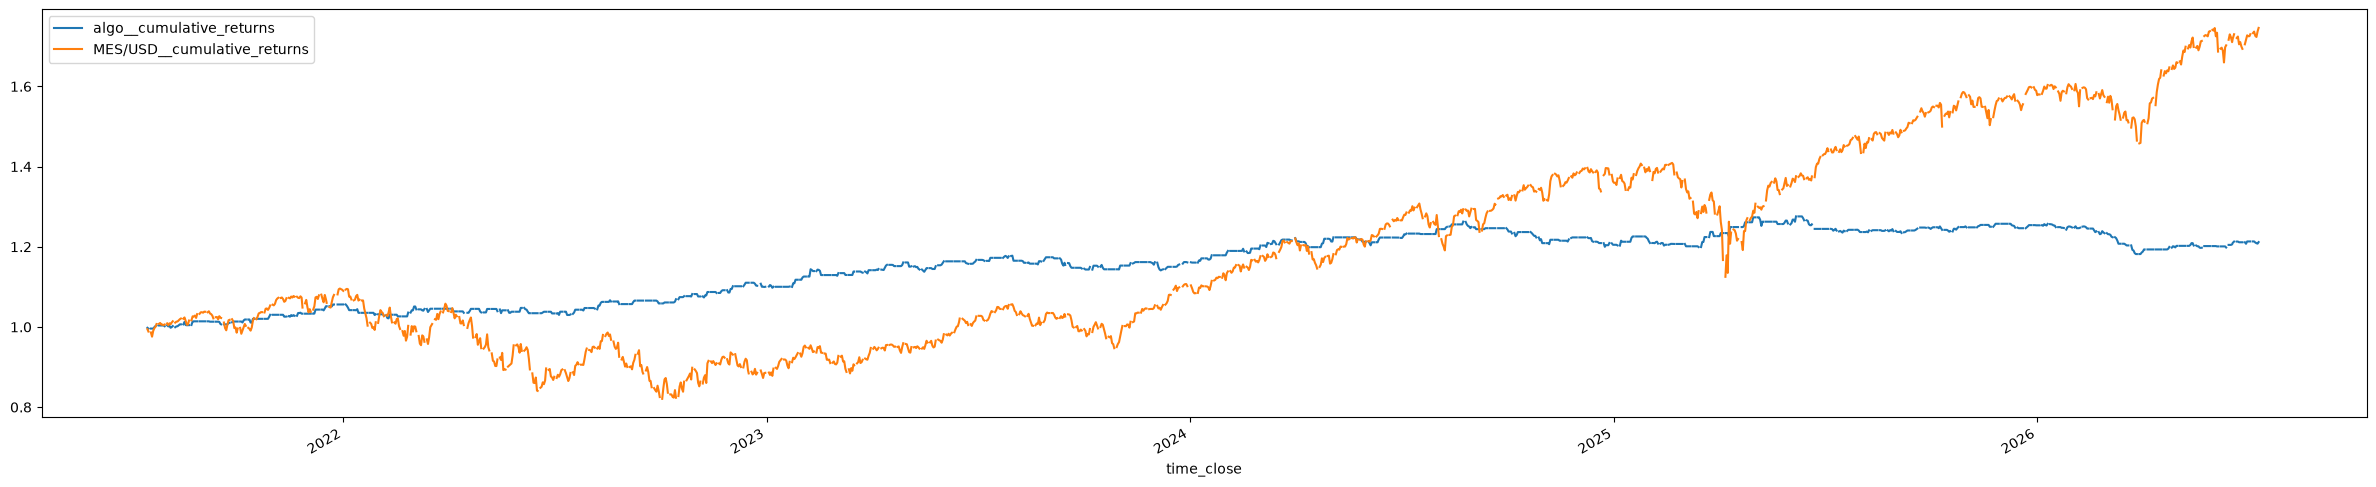

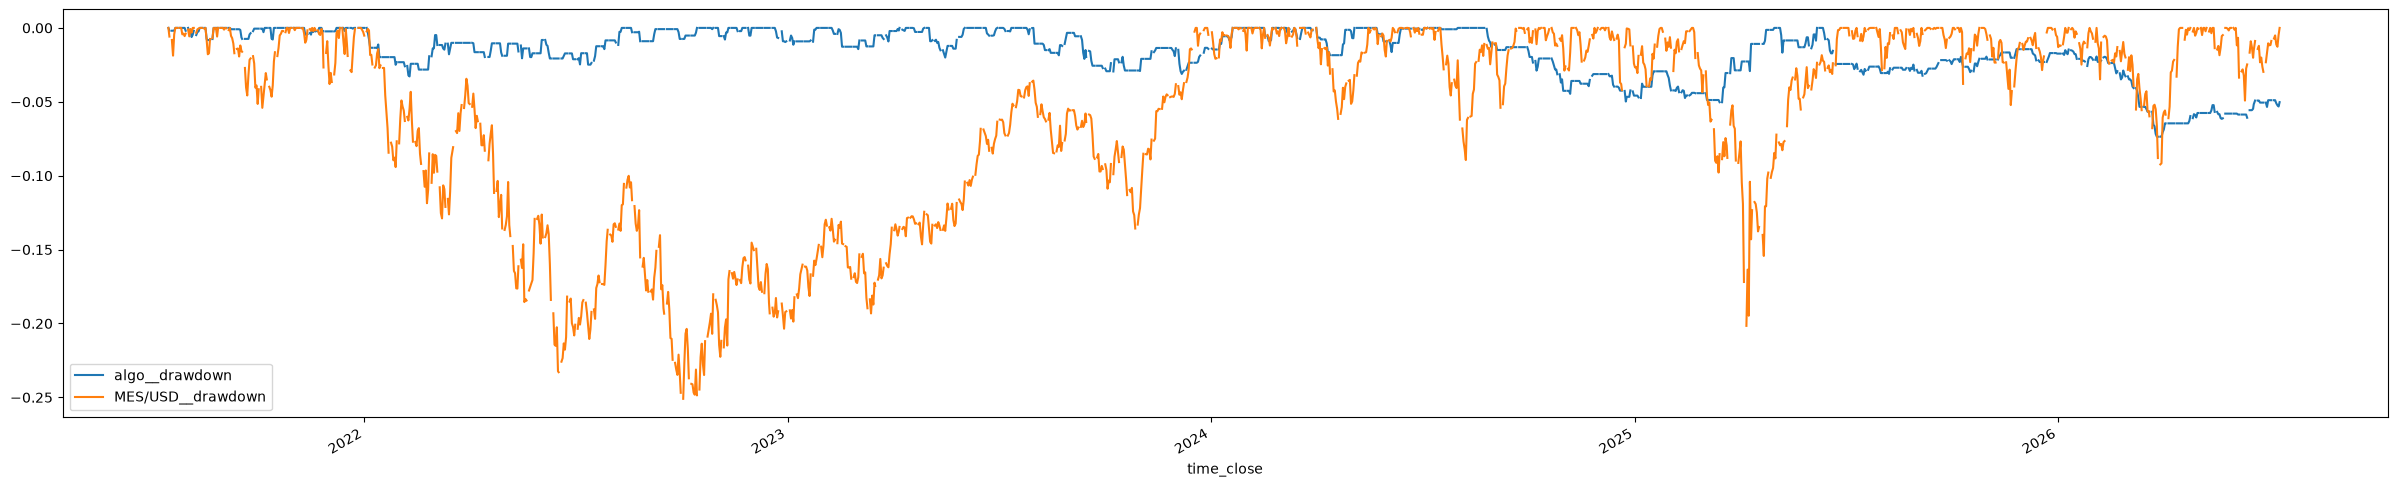

In [7]:
frozen_bt = val_backtests["FROZEN pick"]
display(HTML(frozen_bt.reporter.summary_html_table(split="Y")))

if frozen_bt.reporter.merged is not None:
    frozen_bt.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    frozen_bt.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Findings

**The frozen configuration survived 5 years of unseen data with a positive
Sharpe, and the bracket's risk benefit replicated out of sample -- but the
selection-set numbers shrank by more than half, quantifying exactly how
flattered v1's full-sample result was.**

**What was frozen on the selection set** (first 30%, 2019-05 -> 2021-07):
- Lengths: **KAMA(20) / SMA(7680)** -- and with the widened grid, SMA(7680) is
  now an *interior* optimum, not a boundary artifact: SMA(11520) and SMA(15360)
  columns existed and ranked below it (best 15360 row came 3rd). v1's boundary
  concern is resolved.
- Bracket: **sl=0.0075 (0.75%), tp_ratio=1.5x (tp=1.125%)** -- selection-set
  Sharpe 1.698 vs 1.154 for no-bracket. Notably a much *tighter* bracket than
  v1's full-sample pick (2%/3%): on the 2019-2021 slice, tight-TP profit-taking
  scored best. Sanity check in the table: every row with sl >= 5% and ratio >=
  2x collapses to identical numbers with 0 bracket exits -- those brackets never
  fire, as they shouldn't.

**Validation verdict** (last 70%, 2021-07 -> 2026-07, run once):

| config | net_return | sharpe | max_dd | trades | exits sl/tp/signal |
|---|---|---|---|---|---|
| FROZEN pick (0.75% / 1.125%) | +20.9% | **0.721** | **-7.4%** | 747 | 8 / 125 / 614 |
| no-bracket reference | +32.3% | 0.569 | -10.4% | 747 | 0 / 0 / 747 |
| MES buy-and-hold (same window) | +74.0% | 0.597 | -25.1% | -- | -- |

- **Sharpe degradation: 1.698 (selection) -> 0.721 (validation), -58%.** That
  is the honest price of best-of-25-bracket x best-of-93-lengths selection.
  For calibration, v1's full-sample "Sharpe 0.916" sat between these numbers --
  in-sample optimism, now bounded from both sides.
- **The bracket's core claim replicated**: on unseen data it still improved
  Sharpe (0.721 vs 0.569) and cut max drawdown (-7.4% vs -10.4%) versus the
  same lengths without a bracket, paying for it with net return (+20.9% vs
  +32.3%) -- the same tradeoff shape as in-sample. This is the validated
  finding of the notebook.
- **Year-by-year on validation: positive every full year** (2022 +4.2%, 2023
  +5.5%, 2024 +3.8%, 2025 +4.0%; partial 2021 +5.6%), only the 2026 partial
  negative (-3.6%). Consistency, not streakiness.
- **But the absolute economics are modest**: ~+3.9%/year net on a $50k
  account (~$2k/year) at 149 trades/year, versus buy-and-hold's +74% over the
  same window (with -25.1% drawdown vs the strategy's -7.4%). This
  configuration earns its keep on drawdown control, not on raw return -- as a
  prop-firm sleeve (where the binding constraint is the trailing-drawdown
  limit, not return maximization) that profile is arguably the point; as a
  standalone return vehicle it underwhelms.

**Caveats that remain**: single 30/70 split (a walk-forward with rolling
windows would be stronger evidence than one partition); the selection window
(2019-2021) contains COVID -- a regime-atypical selection set; and the 2026
partial-year loss appears in both this and v1's full-sample run, worth
watching as 2026 data accumulates.


## Portfolio: top-3 selection-set signals at 1/3 weight each, validated on the 70%

The **top 3 length pairs by selection-set `trade_sharpe_lb`** (taken dynamically
from the ranked grid above -- chosen on the first 30% only, same discipline as
everything else) run as three `MaCrossoverStrategy` sleeves in one `Portfolio`
at `weight=1/3` each. Same-symbol long positions net together, so combined
exposure steps through 0% / 33% / 67% / 100% depending on how many signals
agree -- a crude regime vote.

**Disclosures, up front**: (1) the frozen bracket (sl/tp from phase 2) was
tuned on the *#1 signal only*; here it's applied unchanged to all three legs --
still selection-set-only information, but not per-leg-optimized. A no-bracket
portfolio runs alongside for reference. (2) This is *intra-family*
diversification only -- three KAMA/SMA crossovers on one instrument, two of
which share the same slow line. Expect correlated legs and a modest, not
dramatic, smoothing effect; the genuinely-different third leg (a much slower
system, if the selection ranking holds its v-shape) is where most of any
benefit would come from.


In [8]:
TOP_N = 3
top_pairs = [
    (int(r["kama_len"]), int(r["sma_len"]))
    for _, r in sel_ranked.head(TOP_N).iterrows()
]
print(f"Top-{TOP_N} selection-set signals: {top_pairs}")

# Free the single-signal validation market before compiling the portfolio one.
market_val = None
val_backtests = None
gc.collect()

_kama_lens = sorted({k for k, _ in top_pairs})
_sma_lens = sorted({s for _, s in top_pairs})

market_valp = Market()
market_valp.add_market(symbol=SYMBOL, df=df_val)
for k in _kama_lens:
    market_valp.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                              indicator_name=f"kama_{k}",
                              df=Indicators.kama(df, length=k).iloc[split_idx:])
for s in _sma_lens:
    market_valp.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                              indicator_name=f"sma_{s}",
                              df=Indicators.sma(df, s).iloc[split_idx:])
market_valp.compile()
print(f"Portfolio validation market compiled: {len(market_valp.data)} candles")


def _build_leg(kama_len, sma_len, sl, ratio, market_obj):
    bracket_enabled = sl is not None
    return MaCrossoverStrategy(
        key=f"KAMA_{kama_len}_SMA_{sma_len}",
        market=market_obj,
        symbol=SYMBOL,
        direction=StrategyDirection.long,
        fast_indicator_key=f"kama_{kama_len}",
        slow_indicator_key=f"sma_{sma_len}",
        sl_percent=sl if bracket_enabled else 0.99,
        tp_percent=ratio * sl if bracket_enabled else 9.99,
        sl_enabled=bracket_enabled,
        tp_enabled=bracket_enabled,
    )


def run_portfolio_backtest(sl, ratio):
    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0 / TOP_N, strategy=_build_leg(k, s, sl, ratio, market_valp))
        for k, s in top_pairs
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market_valp,
        slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=market_valp, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    market_valp.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=market_valp, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


portfolio_rows = []
portfolio_backtests = {}
for label, sl, ratio in [
    (f"top-{TOP_N} portfolio + frozen bracket", FROZEN_SL, FROZEN_TP_RATIO),
    (f"top-{TOP_N} portfolio, no bracket", None, None),
]:
    if sl is None and FROZEN_SL is None and label.endswith("no bracket"):
        continue
    _t0 = time.time()
    bt, dmw = run_portfolio_backtest(sl, ratio)
    print(f"{label} done in {time.time() - _t0:.1f}s", flush=True)
    row = bracket_row(bt, dmw, sl, ratio)
    row["config"] = label
    portfolio_rows.append(row)
    portfolio_backtests[label] = bt

portfolio_results = pd.DataFrame(portfolio_rows).set_index("config")
combined = pd.concat([portfolio_results, val_results])
print(combined.to_string())


Top-3 selection-set signals: [(20, 7680), (90, 7680), (3840, 15360)]


Portfolio validation market compiled: 1755643 candles


top-3 portfolio + frozen bracket done in 227.1s


top-3 portfolio, no bracket done in 82.6s


                                 sl_percent tp_ratio tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  exits_sl  exits_tp  exits_signal  account_failed
config                                                                                                                                                                                                    
top-3 portfolio + frozen bracket     0.0075      1.5     0.0112            9.145700      0.514153               -6.6931         1360.0         24.926471        79       297           984           False
top-3 portfolio, no bracket            none     none       none           25.970220      0.511957              -10.0263         1359.0         18.910964         0         0          1359           False
FROZEN pick                          0.0075      1.5     0.0112           20.897512      0.721102               -7.3630          747.0         20.749665         8       125           614  

metric,algo,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.5142,2.8420,0.0877,0.8773,0.8523,0.2493,-1.1061,0.5971,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.7948,7.9258,0.1272,1.3437,1.5259,0.3642,-1.4970,0.8795,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,2.4079,2.0535,2.0409,2.6395,2.2967,2.5493,2.7778,14.5886,How much the equity curve swings per year. Lower = smoother.
cagr_percent,1.7667,8.7868,0.2301,3.3683,2.8446,0.8799,-4.4285,11.7197,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.2640,24.4157,0.0901,1.3765,1.0065,0.3810,-0.7927,0.4670,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,1.3664,11.1161,0.0899,1.3726,1.0065,0.3799,-0.4215,2.9479,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-6.6931,-0.3599,-2.5541,-2.4470,-2.8261,-2.3096,-5.5864,-25.0979,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,687,12,218,153,129,240,183,719,How long it took to recover the loss. Shorter is better.
ulcer_index,1.8588,0.1128,1.0635,0.9285,1.1645,1.2105,3.2658,8.9334,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.2292,-0.1025,-0.2277,-0.2332,-0.2004,-0.3026,-0.3371,-1.4184,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


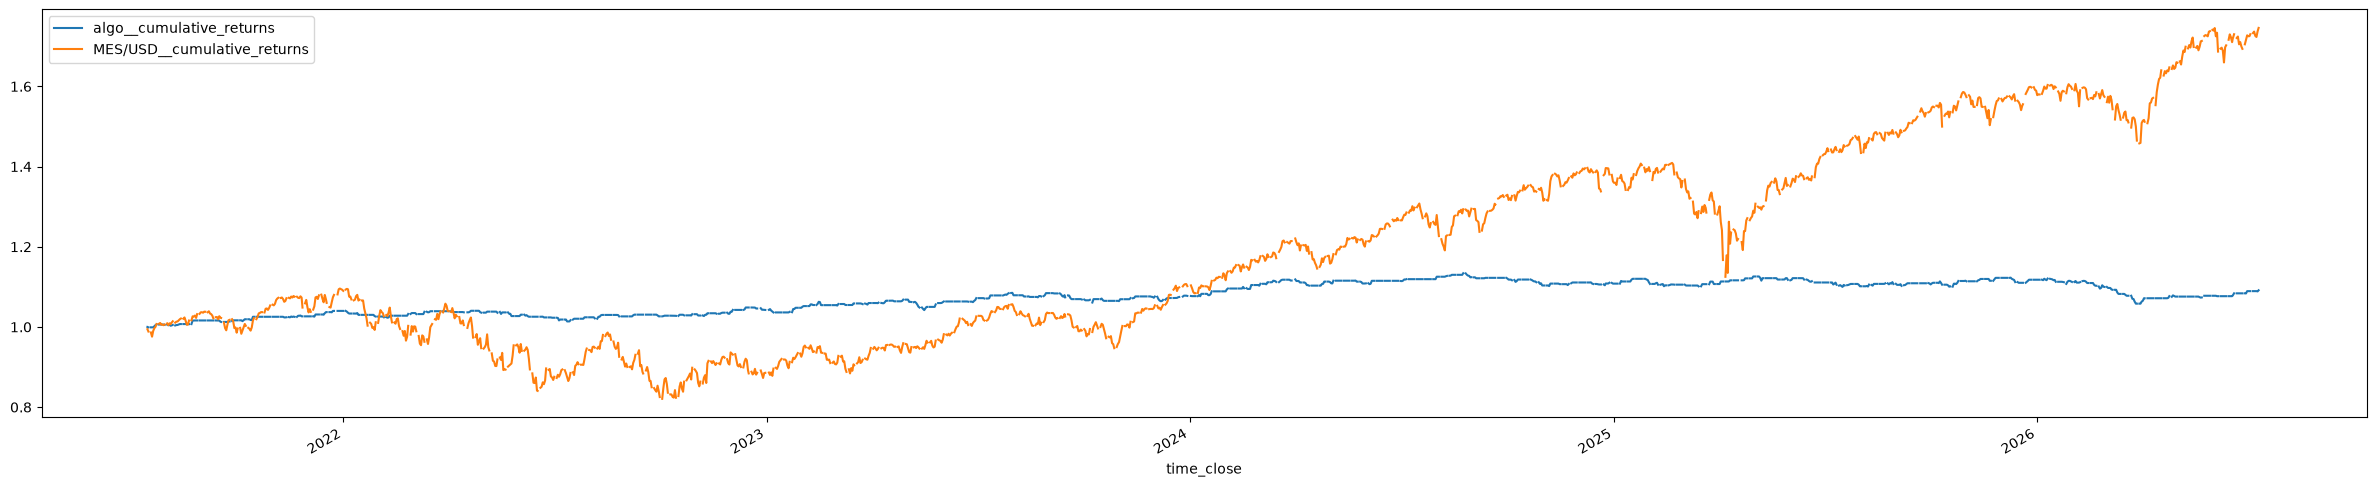

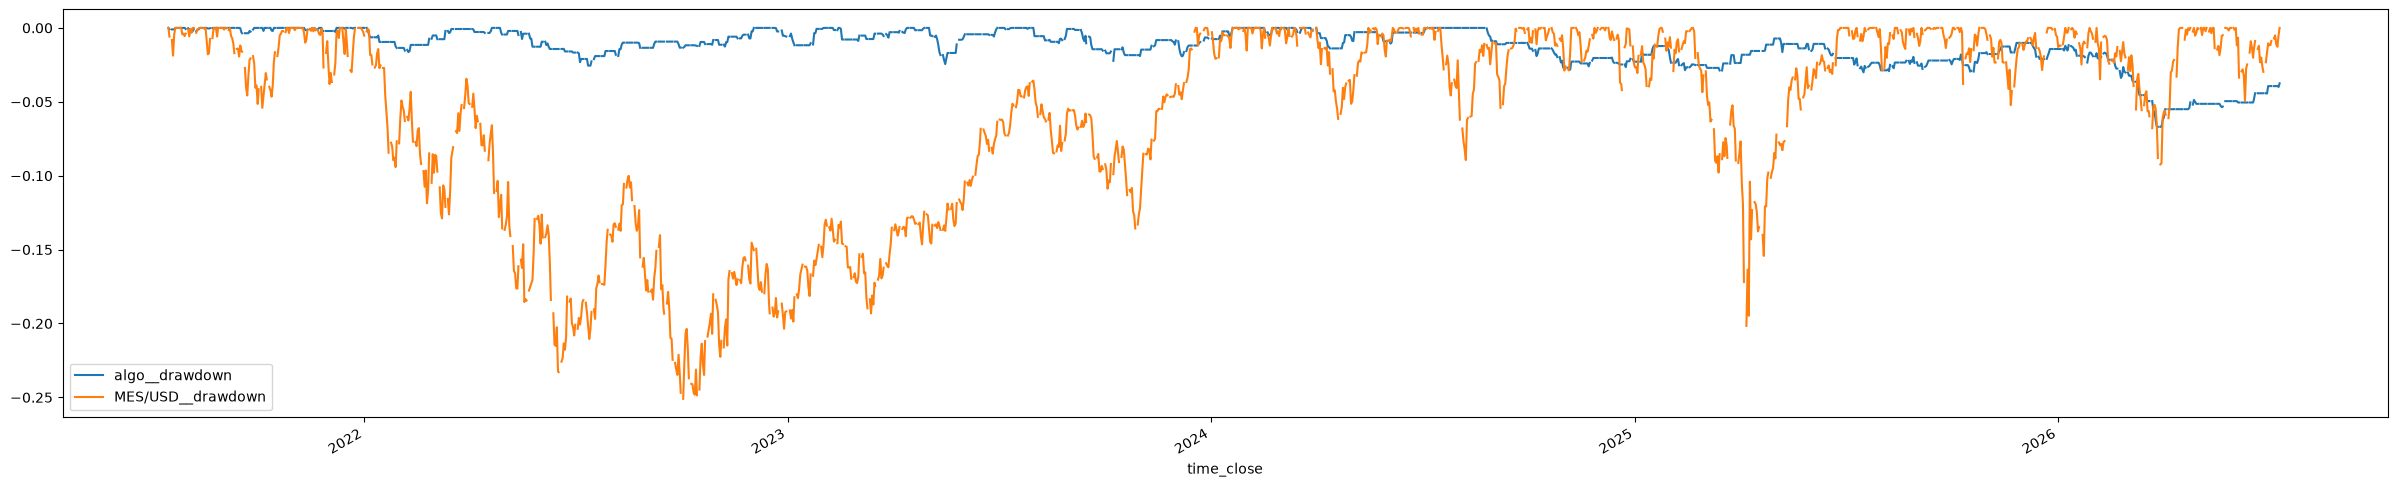

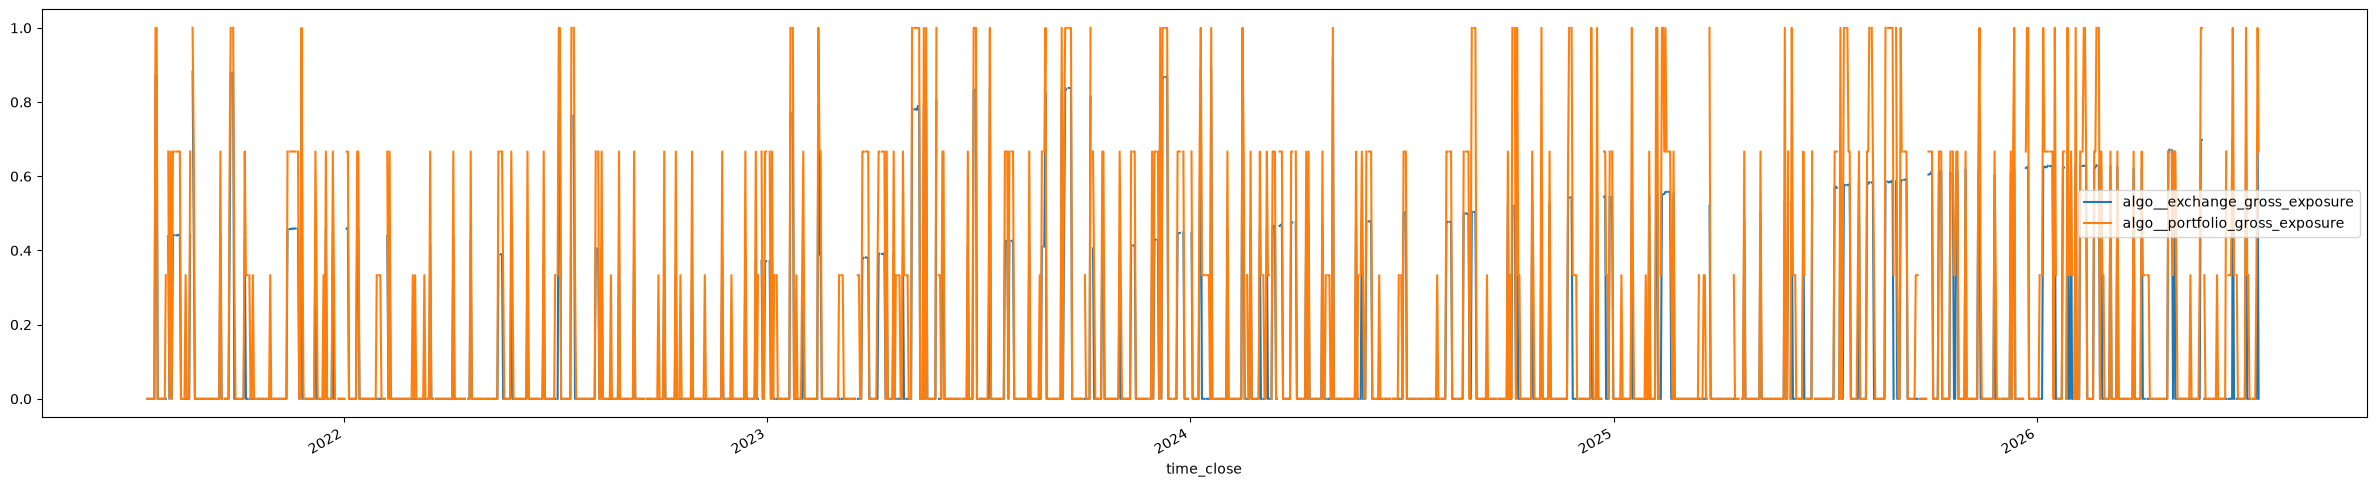

In [9]:
_bracket_label = f"top-{TOP_N} portfolio + frozen bracket"
portfolio_bt = portfolio_backtests[_bracket_label]
display(HTML(portfolio_bt.reporter.summary_html_table(split="Y")))

if portfolio_bt.reporter.merged is not None:
    portfolio_bt.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    portfolio_bt.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))

    portfolio_bt.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_gross_exposure",
        "algo__portfolio_gross_exposure",
    ], figsize=(30, 6))


### Findings: top-3 portfolio

**The portfolio made things worse, not better -- on every axis that matters.**
Validation-window comparison (all configurations frozen on the selection set):

| config | net_return | sharpe | max_dd | trades | exits sl/tp/signal |
|---|---|---|---|---|---|
| single FROZEN pick | +20.9% | **0.721** | -7.4% | 747 | 8 / 125 / 614 |
| single, no bracket | +32.3% | 0.569 | -10.4% | 747 | 0 / 0 / 747 |
| top-3 portfolio, no bracket | +26.0% | 0.512 | -10.0% | 1,359 | 0 / 0 / 1,359 |
| top-3 portfolio + frozen bracket | +9.1% | 0.514 | **-6.7%** | 1,360 | **79** / 297 / 984 |

Two distinct failure mechanisms, worth separating:

1. **The diversification never existed.** Even without any bracket, the
   3-signal portfolio (Sharpe 0.512) underperformed the single signal (0.569).
   Signals #1 and #2 -- KAMA(20)/SMA(7680) and KAMA(90)/SMA(7680) -- share the
   same slow line and differ only in a 20- vs 90-minute fast line: they are
   near-duplicates, so "1/3 + 1/3" of them is mostly just the same position at
   lower conviction sizing plus doubled trade count (1,359 vs 747 -> roughly
   double the fee events for the same underlying signal family). The
   genuinely-different slow leg (KAMA(3840)/SMA(15360)) wasn't strong enough
   out of sample to carry the dilution.

2. **The one-size bracket actively damaged the legs it wasn't tuned for.** The
   frozen 0.75%/1.125% bracket -- chosen on the fast #1 signal -- fired its stop
   **79 times** in the portfolio vs 8 times on the single signal. A
   multi-day-holding slow leg routinely traverses 0.75% adversely as noise, so
   the tight stop amputated it; the tight TP equally truncated the slow leg's
   multi-day winners. Net return collapsed to +9.1%. Lesson: **brackets sized
   as a fraction of entry price do not transfer across signals with different
   holding-period scales** -- a per-leg bracket (or a volatility-scaled one)
   would be the minimum viable design, and its parameters would each need
   their own selection-set search.

The only metric the bracketed portfolio won was max drawdown (-6.7%), and even
that only marginally over the single pick's -7.4% -- at less than half the
return.

**Bottom line**: with intra-family, same-instrument signals this correlated,
equal-weighting the top 3 is not diversification -- it's dilution plus fee
duplication. The single frozen KAMA(20)/SMA(7680) + 0.75%/1.125% configuration
remains this notebook's best validated result (Sharpe 0.721, maxDD -7.4% on
5 unseen years). Portfolio construction becomes worthwhile when the legs are
actually different -- different signal families (e.g. this crossover + the ORB
work in `notebooks/pipelines/breakout/`) or different instruments (MNQ/M2K
data is already on disk) -- not three flavors of the same crossover.


## ATR-scaled bracket: SL/TP as volatility multiples instead of fixed percent

Motivation (from the signal-erosion discussion and the portfolio section's
failure mode): a fixed `sl=0.75%` means something completely different in 2020
volatility than in 2024 volatility -- the parameter itself is non-stationary.
Expressing the bracket as **multiples of the previous day's 14-day ATR**
(`MaCrossoverStrategy`'s new `bracket_atr_key`/`sl_atr_mult`/`tp_atr_mult` mode,
unit-tested, fixed-percent behavior untouched) makes the bracket's *meaning*
constant across regimes with zero refitting -- the alternative to windowed
re-tuning that doesn't add meta-parameters.

Same discipline as everything above: `sl_atr_mult` x TP-ratio searched **on the
selection set only** (frozen KAMA(20)/SMA(7680) lengths unchanged), then the
single frozen ATR bracket validated once on the 70% -- directly comparable to
the fixed-percent bracket's validation row (Sharpe 0.721) and the no-bracket
reference (0.569). The ATR series is lagged one day (`.shift(1)`), so it's
causal by construction; during the ATR's ~15-day warmup at the very start of
the data a trade enters unbracketed rather than being skipped (signal
unchanged, risk overlay unavailable -- affects only the dataset's first days).


In [10]:
# Lagged daily ATR(14), computed once on the FULL 1-minute frame (causal: each
# day's value uses only prior days), then sliced per window below.
_atr_daily = df.resample("D").agg({"high": "max", "low": "min", "close": "last"}).dropna()
_atr_prev_close = _atr_daily["close"].shift(1)
_atr_tr = pd.concat([
    _atr_daily["high"] - _atr_daily["low"],
    (_atr_daily["high"] - _atr_prev_close).abs(),
    (_atr_daily["low"] - _atr_prev_close).abs(),
], axis=1).max(axis=1)
daily_atr_lagged = _atr_tr.rolling(14).mean().shift(1)
atr_bars_full = pd.Series(df.index.normalize().map(daily_atr_lagged), index=df.index)
print(f"ATR as % of price, full history: median "
      f"{(atr_bars_full / prices).median():.3%}, "
      f"5-95%: {(atr_bars_full / prices).quantile(0.05):.3%} - "
      f"{(atr_bars_full / prices).quantile(0.95):.3%}")

# Free the portfolio-section markets before compiling new ones.
market_valp = None
portfolio_backtests = None
portfolio_bt = None
gc.collect()

market_sel_atr = Market()
market_sel_atr.add_market(symbol=SYMBOL, df=df_sel)
market_sel_atr.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                             indicator_name="kama_fast", df=Indicators.kama(df_sel, length=BEST_KAMA_LEN))
market_sel_atr.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                             indicator_name="sma_slow", df=Indicators.sma(df_sel, BEST_SMA_LEN))
market_sel_atr.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                             indicator_name="daily_atr", df=atr_bars_full.iloc[:split_idx])
market_sel_atr.compile()
print(f"ATR selection market compiled: {len(market_sel_atr.data)} candles")


def run_atr_bracket_backtest(market_obj, sl_atr_mult, tp_ratio):
    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=MaCrossoverStrategy(
                key=f"KAMA_{BEST_KAMA_LEN}_SMA_{BEST_SMA_LEN}_ATR",
                market=market_obj,
                symbol=SYMBOL,
                direction=StrategyDirection.long,
                fast_indicator_key="kama_fast",
                slow_indicator_key="sma_slow",
                bracket_atr_key="daily_atr",
                sl_atr_mult=sl_atr_mult,
                tp_atr_mult=tp_ratio * sl_atr_mult,
                sl_enabled=True,
                tp_enabled=True,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market_obj,
        slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=market_obj, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    market_obj.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=market_obj, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


SL_ATR_MULTS = [0.5, 1.0, 1.5, 2.0, 3.0]

atr_sel_rows = []
for sl_mult in SL_ATR_MULTS:
    for ratio in TP_RATIO_CANDIDATES:
        _t0 = time.time()
        bt, dmw = run_atr_bracket_backtest(market_sel_atr, sl_mult, ratio)
        print(f"sl_atr_mult={sl_mult} tp_ratio={ratio} done in {time.time() - _t0:.1f}s", flush=True)
        row = bracket_row(bt, dmw, sl_mult, ratio)
        row["sl_percent"] = f"{sl_mult}xATR"
        row["tp_percent"] = f"{ratio * sl_mult}xATR"
        atr_sel_rows.append(row)

atr_sel_results = pd.DataFrame(atr_sel_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(atr_sel_results.to_string())

_best_atr = atr_sel_results.iloc[0]
FROZEN_SL_ATR_MULT = float(str(_best_atr["sl_percent"]).replace("xATR", ""))
FROZEN_ATR_TP_RATIO = float(_best_atr["tp_ratio"])
print(f"\nFrozen ATR bracket: sl={FROZEN_SL_ATR_MULT}xATR, "
      f"tp={FROZEN_ATR_TP_RATIO * FROZEN_SL_ATR_MULT}xATR "
      f"(selection Sharpe {_best_atr['sharpe_ratio']:.3f} vs fixed-percent frozen "
      f"{sel_bracket_results.iloc[0]['sharpe_ratio']:.3f})")


ATR as % of price, full history: median 1.147%, 5-95%: 0.672% - 2.541%


ATR selection market compiled: 752418 candles


sl_atr_mult=0.5 tp_ratio=1.5 done in 59.8s


sl_atr_mult=0.5 tp_ratio=2.0 done in 139.9s


sl_atr_mult=0.5 tp_ratio=3.0 done in 36.0s


...

sl_atr_mult=2.0 tp_ratio=3.0 done in 66.4s


sl_atr_mult=3.0 tp_ratio=1.5 done in 24.0s


sl_atr_mult=3.0 tp_ratio=2.0 done in 31.3s


sl_atr_mult=3.0 tp_ratio=3.0 done in 28.0s


   sl_percent  tp_ratio tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  exits_sl  exits_tp  exits_signal  account_failed
0     1.5xATR       3.0    4.5xATR           48.608760      1.241689               -8.0974          257.0         22.957198         0         6           251           False
1     3.0xATR       1.5    4.5xATR           48.608760      1.241689               -8.0974          257.0         22.957198         0         6           251           False
2     2.0xATR       3.0    6.0xATR           47.711974      1.216639               -8.0867          257.0         22.957198         0         2           255           False
3     3.0xATR       2.0    6.0xATR           47.711974      1.216639               -8.0867          257.0         22.957198         0         2           255           False
4     0.5xATR       1.5   0.75xATR           23.548967      1.202399               -4.4579          258.0         28.294574       

ATR validation market compiled: 1755643 candles


FROZEN ATR bracket validation done in 94.8s


                     sl_percent tp_ratio tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  exits_sl  exits_tp  exits_signal  account_failed
config                                                                                                                                                                                        
FROZEN ATR bracket      1.5xATR      3.0    4.5xATR           34.354636      0.602637              -10.2285          747.0         16.331995         0         9           738           False
FROZEN pick              0.0075      1.5     0.0112           20.897512      0.721102               -7.3630          747.0         20.749665         8       125           614           False
no-bracket reference       none     none       none           32.323960      0.568618              -10.4077          747.0         16.331995         0         0           747           False


metric,algo,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,0.6026,2.0396,0.0141,0.9396,1.8607,0.0733,-0.5133,0.5971,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,0.8936,3.6554,0.0212,1.4748,3.2588,0.0962,-0.7259,0.8795,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,7.2013,5.5167,9.5960,6.0743,5.9899,8.3705,4.3695,14.5886,How much the equity curve swings per year. Lower = smoother.
cagr_percent,6.0876,17.4396,-0.4678,8.3518,17.2627,0.3800,-3.3467,11.7197,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,0.5952,7.2309,-0.0688,1.7231,6.1359,0.0394,-0.5030,0.4670,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,3.3587,3.2235,-0.0686,1.7182,6.1359,0.0393,-0.2667,2.9479,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-10.2285,-2.4118,-6.7988,-4.8469,-2.8134,-9.6390,-6.6533,-25.0979,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,581,42,135,160,53,342,183,719,How long it took to recover the loss. Shorter is better.
ulcer_index,3.2290,0.7877,2.8453,2.3246,1.0576,3.9068,2.8896,8.9334,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.6623,-0.4779,-0.9871,-0.5954,-0.5444,-0.6993,-0.4144,-1.4184,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


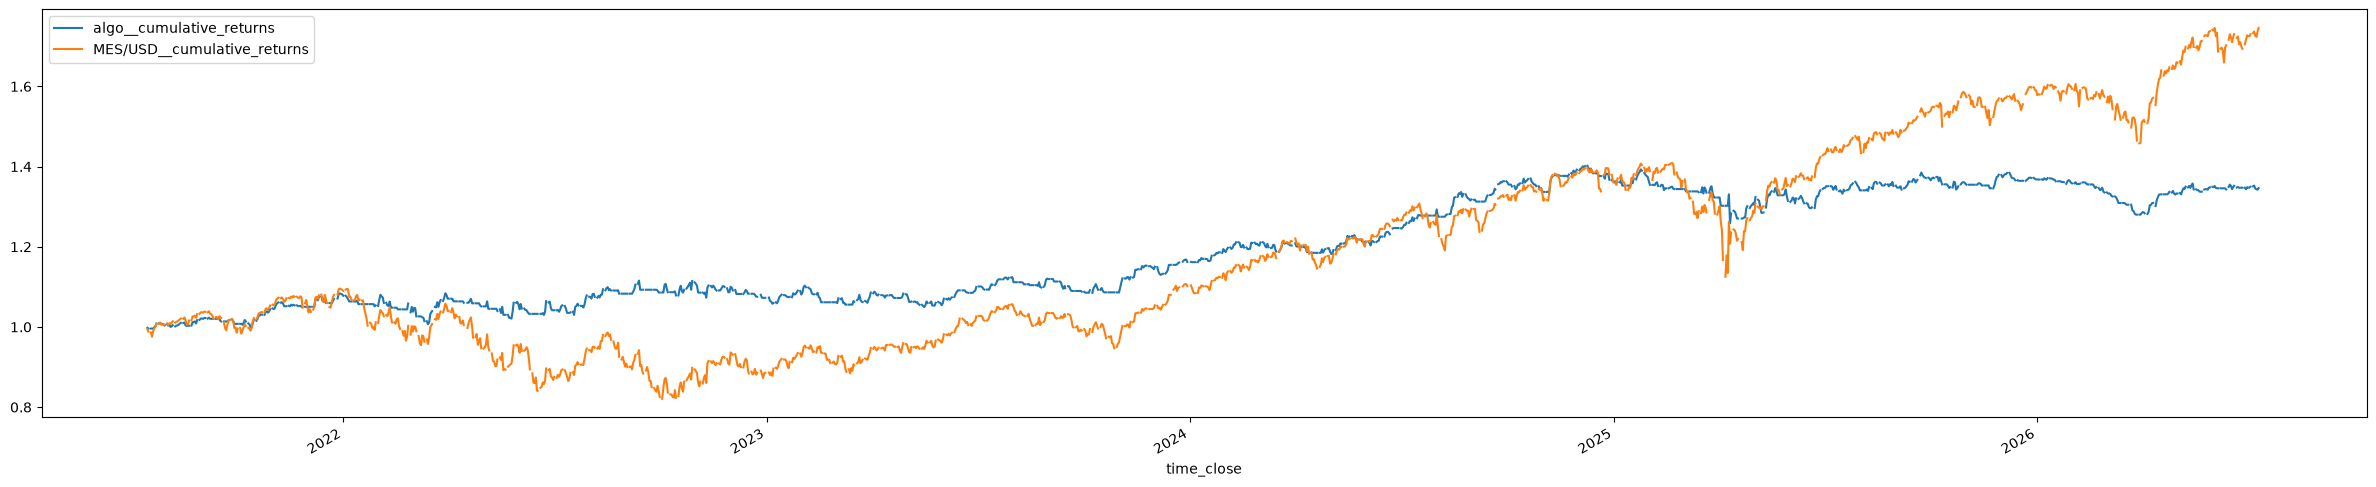

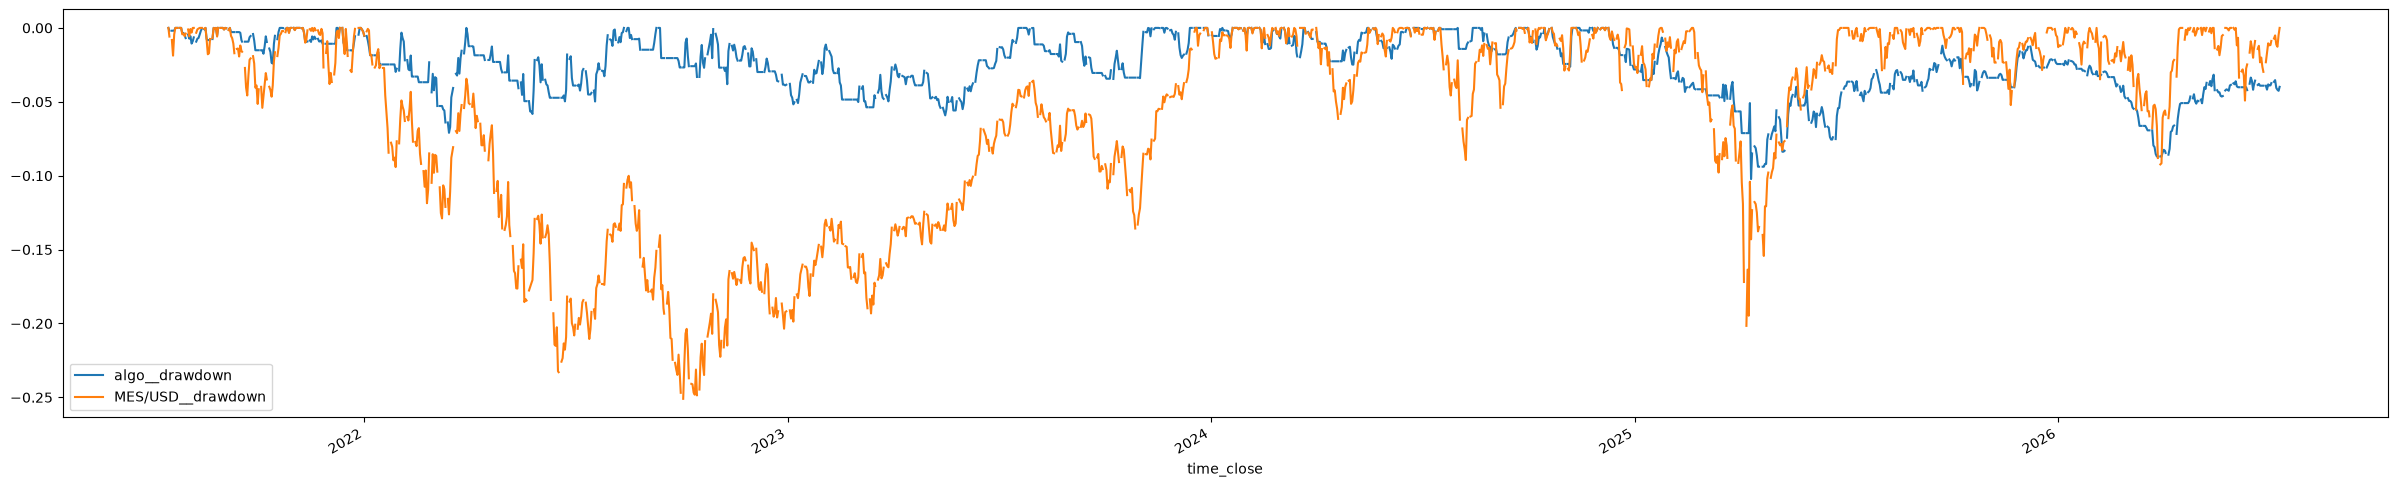

In [11]:
market_sel_atr = None
gc.collect()

market_val_atr = Market()
market_val_atr.add_market(symbol=SYMBOL, df=df_val)
market_val_atr.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                             indicator_name="kama_fast", df=kama_full.iloc[split_idx:])
market_val_atr.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                             indicator_name="sma_slow", df=sma_full.iloc[split_idx:])
market_val_atr.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                             indicator_name="daily_atr", df=atr_bars_full.iloc[split_idx:])
market_val_atr.compile()
print(f"ATR validation market compiled: {len(market_val_atr.data)} candles")

_t0 = time.time()
atr_val_bt, atr_val_dmw = run_atr_bracket_backtest(market_val_atr, FROZEN_SL_ATR_MULT, FROZEN_ATR_TP_RATIO)
print(f"FROZEN ATR bracket validation done in {time.time() - _t0:.1f}s", flush=True)

atr_val_row = bracket_row(atr_val_bt, atr_val_dmw, FROZEN_SL_ATR_MULT, FROZEN_ATR_TP_RATIO)
atr_val_row["sl_percent"] = f"{FROZEN_SL_ATR_MULT}xATR"
atr_val_row["tp_percent"] = f"{FROZEN_ATR_TP_RATIO * FROZEN_SL_ATR_MULT}xATR"
atr_val_row["config"] = "FROZEN ATR bracket"

atr_comparison = pd.concat([
    pd.DataFrame([atr_val_row]).set_index("config"),
    val_results,
])
print(atr_comparison.to_string())

display(HTML(atr_val_bt.reporter.summary_html_table(split="Y")))

if atr_val_bt.reporter.merged is not None:
    atr_val_bt.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    atr_val_bt.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


### Findings: ATR-scaled bracket

**The ATR bracket did not beat the fixed-percent bracket out of sample -- but
the reason is more instructive than the headline.** Validation comparison
(all frozen on the selection set):

| config | net_return | sharpe | max_dd | exits sl/tp/signal |
|---|---|---|---|---|
| FROZEN fixed-percent (0.75%/1.125%) | +20.9% | **0.721** | **-7.4%** | 8 / 125 / 614 |
| FROZEN ATR bracket (1.5x/4.5xATR) | +34.4% | 0.603 | -10.2% | 0 / **9** / 738 |
| no-bracket reference | +32.3% | 0.569 | -10.4% | 0 / 0 / 747 |

**What actually happened in selection**: with median daily ATR ~1.15% of
price, the chosen 1.5xATR stop (~1.7%) and 4.5xATR target (~5.2%) are so wide
they almost never fire -- 6 TP exits in 257 selection trades, and the grid is
full of degenerate duplicates (any (mult, ratio) pair with the same product
and a never-firing stop produces identical results). **Selection-set Sharpe
preferred an effectively inert bracket** (1.242) over the genuinely active
tight options (0.5xATR/1.5x: Sharpe 1.202, 65 TP exits -- the ATR-mode
equivalent of the fixed 0.75% winner, ranked 5th). So the frozen "ATR bracket"
that went to validation is, functionally, the no-bracket configuration with a
rare profit-taker attached -- and its validation numbers confirm it (Sharpe
0.603 vs no-bracket's 0.569, nearly identical drawdown).

**On the stationarity thesis this section was meant to test**: inconclusive,
not refuted. Selection->validation Sharpe shrinkage was -51% for the ATR pick
vs -58% for fixed-percent -- marginally smaller, but since the ATR pick barely
does anything, that's mostly measuring the shrinkage of the underlying signal,
not of the bracket. The interesting untested cell is 0.5xATR/1.5x -- the
active ATR bracket that would genuinely test "does a volatility-scaled tight
bracket transfer better than a fixed-percent tight bracket." Under this
notebook's protocol (validate only the frozen selection winner) it wasn't
eligible; a follow-up could pre-register exactly that comparison, but note it
would be a second bite at the selection apple and should be labeled
accordingly.

**Standing result unchanged**: fixed-percent 0.75%/1.125% on KAMA(20)/SMA(7680)
remains the best validated configuration (Sharpe 0.721, maxDD -7.4% on 5 unseen
years). One process lesson worth keeping: when a bracket search's winner has
near-zero exit counts, the search has effectively concluded "no bracket" --
rank-by-Sharpe can't distinguish inert configurations from each other, and
tie-broken duplicates in the table are the tell.
